### Analisis y procesamiento de señales - UNSAM <img src=./logo_UNSAM.jpg align = right width = 150>\n",
## TS2: Modelizando un ADC
### Jeronimo Lanzavechia

### Consigna
En esta tarea semanal retomamos la consigna de la tarea anterior, donde simulamos el bloque de cuantización de un ADC de B bits en un rango de  ±VF Volts. Ahora vamos a completar la simulación del ADC incluyendo la capacidad de muestrear a fs Hertz.

Para ello se simulará el comportamiento del dispositivo al digitalizar una senoidal contaminada con un nivel predeterminado de ruido. Comenzaremos describiendo los parámetros a ajustar de la senoidal:

- frecuencia f0 arbitraria, por ejemplo f0=fS/N=Δf 
- energía normalizada, es decir energía (o varianza) unitaria

Con respecto a los parámetros de la secuencia de ruido, diremos que:

- será de carácter aditivo, es decir la señal que entra al ADC será sR=s+n. Siendo n la secuencia que simula la interferencia, y s la senoidal descrita anteriormente.
- La potencia del ruido será Pn=kn.Pq W siendo el factor k una escala para la potencia del ruido de cuantización Pq=(q^2)/12.
    finalmente, n será incorrelado y Gaussiano.

El ADC que deseamos simular trabajará a una frecuencia de muestreo fS=1000 Hz y tendrá un rango analógico de ±VF=2 Volts.

Se pide:

a) Generar el siguiente resultado producto de la experimentación. B = 4 bits, kn=1.

b) Analizar para una de las siguientes configuraciones B = ̣{4, 8 y 16} bits, kn={1/10,1,10}. Discutir los resultados respecto a lo obtenido en a).

### Implementación de ADC
En mi_libreria se encuentran implementados el espectrometro y el digitalizador. El espectrometro devuelve el vector de frecuencias, la densidad de potencia y el desplazamiento de fase. El digitalizador devuelve la señal digitalizada.

In [14]:
#hecha en clase
def digitalizador (signal,q,n,fs):
    tt = np.arange(start = 0, stop = fs/n, step = 1/fs)
    xx =  q * np.round(signal/q)
    return tt,xx

#hecha en clase
def spectometer (signal,n,fs,ref):
    ww = np.arange(start = 0, stop = fs/2, step = fs/n)
    #transformo la señal
    trafo_signal_N = scfft.fft(signal,n)
    trafo_signal = 1/(n) * trafo_signal_N[:n//2]
    #doy modulo y fase
    modulo_trafo_signal = np.abs(2*trafo_signal)
    fase_trafo_signal = np.angle(trafo_signal)
    modulo_db = 20 * np.log10(modulo_trafo_signal/ref)
    return ww,modulo_db,fase_trafo_signal
    

a) Generar el siguiente resultado producto de la experimentación. B = 4 bits, kn=1.

Aclaración: El formateo de los gráficos como subplots se hizo con asistencia de chat-gpt.

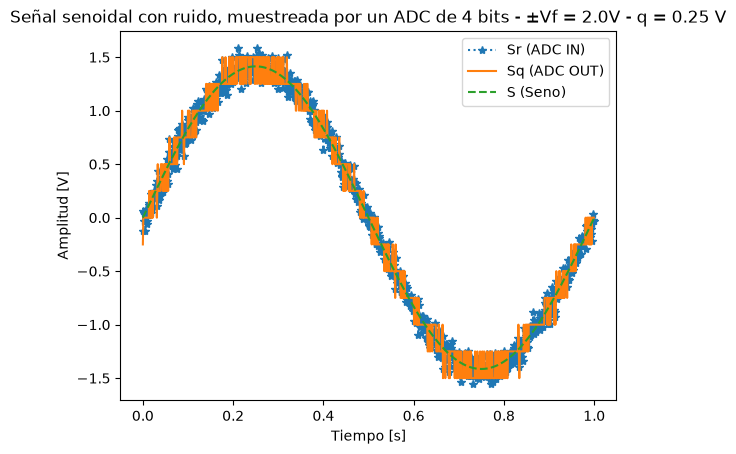

In [15]:
import numpy as np
import matplotlib.pyplot as plt
import mi_libreria as lib

fs = 1000
N = 1000

f0 = fs/N

B = 4
Vfs = 2
q = (Vfs*2)/(2**B)
kn = 1
Pq = (q**2)/12
Pn = kn * Pq
A_seno = np.sqrt(2)
#Sr = s + n

tt,n = lib.mi_ruido(Pn, "normal", 0, N, fs)

tt,s = lib.mi_funcion_seno(A_seno, 0, f0, 0, N, fs)

Sr = s + n

tt,Sq = lib.digitalizador(Sr, q, N, fs)

plt.figure(1)
plt.title(f"Señal senoidal con ruido, muestreada por un ADC de 4 bits - ±Vf = 2.0V - q = {q:.2f} V")
plt.plot(tt,Sr, ':*')
plt.plot(tt,Sq)
plt.plot(tt,s,'--')
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud [V]")
plt.legend(("Sr (ADC IN)","Sq (ADC OUT)","S (Seno)"))

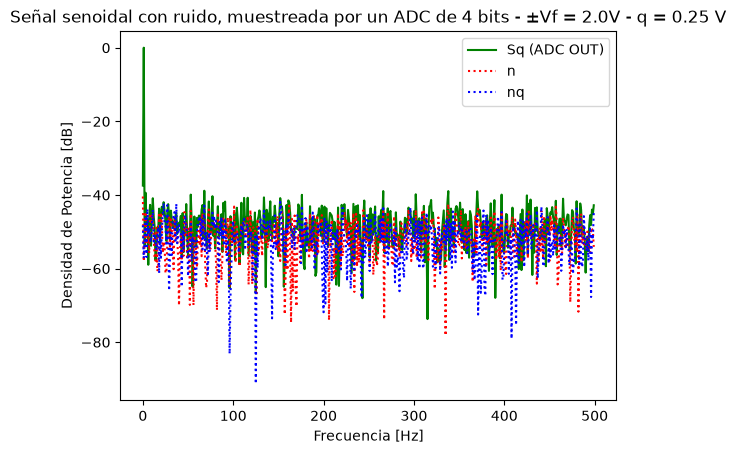

In [16]:
plt.figure(2)
plt.title(f"Señal senoidal con ruido, muestreada por un ADC de 4 bits - ±Vf = 2.0V - q = {q:.2f} V")
ww,Sq_g,Sq_f = lib.spectometer(Sq, N, fs, A_seno)

ww,n_g,n_f = lib.spectometer(n, N, fs, A_seno)

nq = Sr - Sq

ww,nq_g,nq_f = lib.spectometer(nq, N, fs, A_seno)

ww,n_g,n_f = lib.spectometer(n, N, fs, A_seno)

ww,Sr_g,Sr_f = lib.spectometer(Sr, N, fs, A_seno)

plt.plot(ww,Sq_g, color = 'green')
plt.plot(ww,n_g,':', color = 'red')
plt.plot(ww,nq_g,':', color = 'blue')

plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Densidad de Potencia [dB]")
plt.legend(("Sq (ADC OUT)","n","nq"))

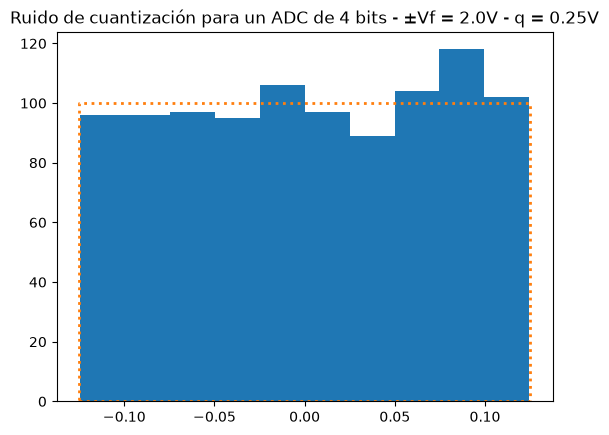

In [17]:
plt.figure(3)
plt.title("Ruido de cuantización para un ADC de 4 bits - ±Vf = 2.0V - q = 0.25V")
plt.hist(nq)
plt.plot(
    [-q/2, q/2, q/2, -q/2, -q/2],
    [0, 0, 100, 100, 0],
    linestyle=':',
    linewidth=2
)

b) Analizar para una de las siguientes configuraciones B = ̣{4, 8 y 16} bits, kn={1/10,1,10}. Discutir los resultados respecto a lo obtenido en a).

Para este analisis: Kn = 10, B = 8 bits

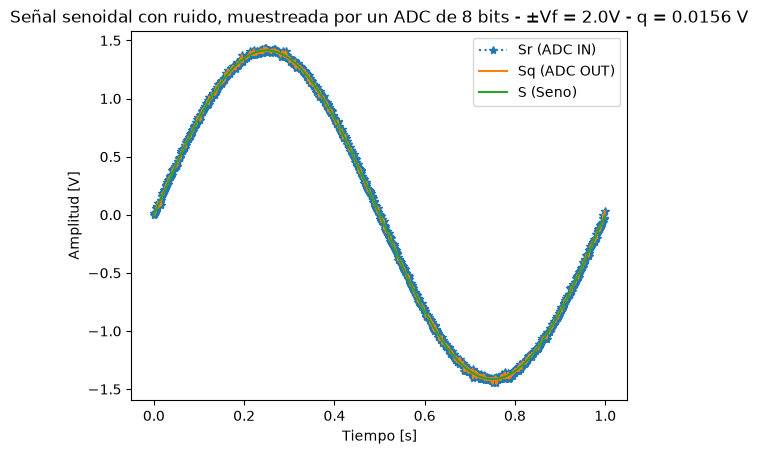

In [18]:
B = 8
Vfs = 2
q = (Vfs*2)/(2**B)
kn = 10
Pq = (q**2)/12
Pn = kn * Pq
A_seno = np.sqrt(2)
#Sr = s + n

tt,n = lib.mi_ruido(Pn, "normal", 0, N, fs)

tt,s = lib.mi_funcion_seno(A_seno, 0, f0, 0, N, fs)

Sr = s + n

tt,Sq = lib.digitalizador(Sr, q, N, fs)

plt.figure(4)
plt.title(f"Señal senoidal con ruido, muestreada por un ADC de 8 bits - ±Vf = 2.0V - q = {q:.4f} V")
plt.plot(tt,Sr, ':*')
plt.plot(tt,Sq)
plt.plot(tt,s)
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud [V]")
plt.legend(("Sr (ADC IN)","Sq (ADC OUT)","S (Seno)"))

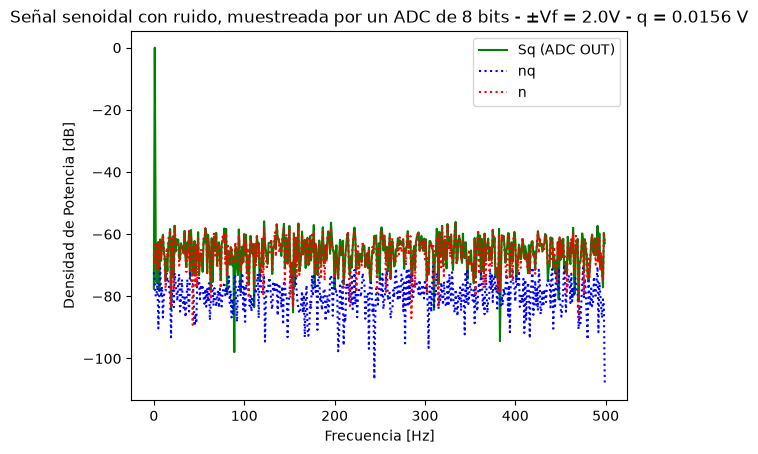

In [19]:
plt.figure(5)
plt.title(f"Señal senoidal con ruido, muestreada por un ADC de 8 bits - ±Vf = 2.0V - q = {q:.4f} V")
ww,Sq_g,Sq_f = lib.spectometer(Sq, N, fs, A_seno)

ww,n_g,n_f = lib.spectometer(n, N, fs, A_seno)

nq = Sr - Sq

ww,nq_g,nq_f = lib.spectometer(nq, N, fs, 2)

plt.plot(ww,Sq_g, color = 'green')
plt.plot(ww,nq_g,':', color = 'blue')
plt.plot(ww,n_g,':', color = 'red')

plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Densidad de Potencia [dB]")
plt.legend(("Sq (ADC OUT)","nq","n"))

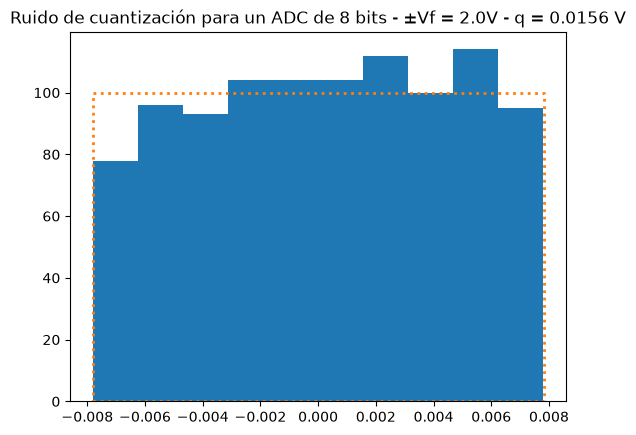

In [20]:
plt.figure(6)
plt.title(f"Ruido de cuantización para un ADC de 8 bits - ±Vf = 2.0V - q = {q:.4f} V")
plt.hist(nq)
plt.plot(
    [-q/2, q/2, q/2, -q/2, -q/2],
    [0, 0, 100, 100, 0],
    linestyle=':',
    linewidth=2
)

### Comparación

Al configurar la potencia de ruido por K y q, al aumentar q y K, aumentaria la potencia del ruido.
Como q depende de la cantidad de bits, al aumentarlo, el valor de q baja. Con 8 bits, q tiene un valor inferior al del punto (a), y con k = 10, multiplicamos ese valor en 10. El cambio que produce un q mas chico en la generación de nuestro ruido es mucho mas significativo al tener un efecto cuadrático en la potencia. K tendrá un efecto lineal sobre la potencia.

#### En el tiempo 
El ruido en la señal de b) es mucho menor que el de la señal en a), por el q mas bajo, y hace que los valores que pueda tomar el ruido esten limitados. Una digitalizacion de 8 bits tendra como efecto tomar valores mas cercanos a la señal de entrada por el paso de cuantización mas pequeño. En cada paso de quantización hay menos valores de tensión que puede tomar la señal de entrada.

#### En frecuencia
Al tener una potencia de ruido mas baja, el piso analógico sera mucho mas bajo, pero como la cantidad de bits disponibles son mayores, la señal analógica tendra mucha mas cercania a la señal digital que produce el ADC. El ruido de cuantización sera más bajo en este caso, con 8 bits, que en el caso de 4 bits. El piso digital será menor que el piso analógico.

#### Ruido de Cuantización
Al q del (b (15,6mV) ser menor que el q de (a (250mV), la potencia del ruido se ve afectada. Los valores de tensión posibles son de menor amplitud. El histograma se ve reducido en valores de amplitud, pero al no cambiar la cantidad de muestras, el total de valores se mantiene. Un cambio en K deberia aumentarme linealmente la potencia del ruido, por ende, cambiando la amplitud que podrian tomarse en las muestras del ruido de cuantización.

No hace bonus.